# Bilateral Corridor Use Case — US→China / China→Taiwan

Analyzes `bilateral_test_metrics.csv`, produced by `test_bilateral_pairs.py`, which
evaluates every trained model (7 GAT variants, 12 EdgeGAT_full variants, 3 RF baselines)
on two fixed bilateral corridors carved out of the 2023 test set:

- **US → China** (reporterCode=842, partnerCode=156)
- **China → Taiwan** (reporterCode=156, partnerCode=490 — Comtrade's "Other Asia, nes"
  code; Taiwan isn't its own reporter/partner entity in Comtrade, same carve-out used
  throughout the GDELT↔Comtrade ISO3→M49 bridge)

**Structure:** each corridor gets its own fully independent section (Part 1, Part 2) —
overview table, log-R², spearman, error metrics (MAE/RMSE/SMAPE), best-of-family
comparison, GDELT lift, and the R²-vs-log-R² agreement check, all scoped to that one
corridor only. Part 3 puts the two side by side.

**Read this before trusting the numbers below:**
- **n=19 per corridor.** Each row is one HS-heading × 2023 for that corridor — small,
  high-variance sample. Don't over-read small differences between models here.
- **Single test year (2023).** No time dimension in this file — every metric is a
  snapshot, not a trend. A predicted-vs-actual time series across 2017–2023 (annotated
  with known events like the Oct-2022 export controls) is flagged as future work.
- **The CSV may have been appended across multiple runs** — the load cell dedupes to
  the latest successful row per (model, country_pair) automatically.
- **Every model here predicts a reporter's aggregated trade value**, not a genuinely
  bilateral flow by architecture — the "bilateral" framing comes from filtering the
  evaluation frame down to one fixed partner *before* aggregation, so the aggregate
  collapses to that corridor's value. See `test_bilateral_pairs.py`'s docstring for
  the full reasoning.

In [12]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import os

plt.style.use('default')
plt.rcParams.update({
    'figure.facecolor': '#ffffff', 'axes.facecolor': '#ffffff', 'savefig.facecolor': '#ffffff',
    'axes.edgecolor': '#000000', 'axes.labelcolor': '#000000',
    'text.color': '#000000', 'xtick.color': '#000000', 'ytick.color': '#000000',
    'axes.grid': True, 'grid.color': '#000000', 'grid.alpha': 0.15, 'font.size': 10,
})
BLUE, ORANGE, POS, NEG, PURPLE, GRAY = '#4c8fbd', '#c47f3e', '#2ca02c', '#d62728', '#9467bd', '#888888'
KIND_COLOR = {'GAT': BLUE, 'EdgeGAT_full': ORANGE, 'RF': PURPLE}

# ---- if auto-detection below doesn't find the file, just set this directly ----
CSV_OVERRIDE_PATH = None   # e.g. '/home/hefouzinho/electronic_prods_pred/bilateral_test_metrics.csv'

# Tries repo conventions from a few plausible working directories: repo root,
# notebooks/0X_.../ (two levels down from repo root, matching this repo's layout),
# and the current directory as a last resort.
CANDIDATE_DIRS = [
    'results/grids', '../../results/grids', '.',
    os.path.expanduser('~/electronic_prods_pred'),
    os.path.expanduser('~/electronic_prods_pred/results/grids'),
]

def find_file(fname):
    if CSV_OVERRIDE_PATH and os.path.exists(CSV_OVERRIDE_PATH):
        return CSV_OVERRIDE_PATH
    for d in CANDIDATE_DIRS:
        p = os.path.join(d, fname)
        if os.path.exists(p):
            return p
    return None

path = find_file('bilateral_test_metrics.csv')
found_label = 'found' if path else 'MISSING'
print(f'  [{found_label}]  bilateral_test_metrics.csv -> {path or "bilateral_test_metrics.csv"}')
if not path:
    print('  -> not found in any CANDIDATE_DIRS. Set CSV_OVERRIDE_PATH above to the exact file path and rerun this cell.')

raw = pd.read_csv(path) if path else pd.DataFrame(
    columns=['timestamp','model','kind','use_gdelt','scoring','fusion','agg_mode',
             'country_pair','n','mae','rmse','r2','log_r2','spearman','smape','notes'])
print(f'{len(raw)} raw rows loaded')

# ---- dedupe: keep the LATEST successful row per (model, country_pair) ----
# "successful" = n > 0 and notes is empty/NaN (drops crashed/weights-not-found rows
# from any earlier run before the EdgeGAT self-loop fix).
df = raw.copy()
df['notes'] = df['notes'].fillna('')
ok = df[(df['n'] > 0) & (df['notes'] == '')].copy()
ok = ok.sort_values('timestamp').drop_duplicates(['model', 'country_pair'], keep='last')

dropped = len(raw) - len(ok)
print(f'{len(ok)} clean rows kept after dedup ({dropped} duplicate/failed rows dropped)')

missing = df[(df['n'] == 0) | (df['notes'] != '')][['model', 'country_pair', 'notes']].drop_duplicates('model')
if len(missing):
    print('')
    print('Models with at least one still-unresolved (model, country_pair) cell:')
    print(missing.to_string(index=False))

df = ok
COUNTRY_PAIRS = sorted(df['country_pair'].unique().tolist())
print('')
print(f'corridors: {COUNTRY_PAIRS}')

  [found]  bilateral_test_metrics.csv -> /home/hefouzinho/electronic_prods_pred/bilateral_test_metrics.csv
88 raw rows loaded
44 clean rows kept after dedup (44 duplicate/failed rows dropped)

Models with at least one still-unresolved (model, country_pair) cell:
                       model country_pair                                                                                                notes
   EdgeGAT_full_concat_ka_ka  US_to_China error: Found array with 0 sample(s) (shape=(0, 5)) while a minimum of 1 is required by MinMaxScaler.
    EdgeGAT_full_blend_ka_ka  US_to_China error: Found array with 0 sample(s) (shape=(0, 5)) while a minimum of 1 is required by MinMaxScaler.
EdgeGAT_full_attention_ka_ka  US_to_China error: Found array with 0 sample(s) (shape=(0, 5)) while a minimum of 1 is required by MinMaxScaler.
   EdgeGAT_full_concat_tk_tk  US_to_China error: Found array with 0 sample(s) (shape=(0, 5)) while a minimum of 1 is required by MinMaxScaler.
    EdgeGAT_full_blend

### Mosaic helper

Every metric gets its own independent figure (never combined subplots), so any single
plot can be saved on its own — same convention as `compare_all_experiments_v3.ipynb` /
`feature_importance_analysis.ipynb` / `log_metrics_comparison_suite.ipynb`.

In [13]:
def plot_metric_mosaic(index, series, metrics, metric_labels=None, title_prefix='',
                       orientation='horizontal', panel_size=(7, 6), value_fmt=None, rotation=30):
    '''index: list of category/model labels
    series: {series_label: {metric_name: array-like aligned with index}}
    metrics: candidate metric names -- only ones present in EVERY series are actually plotted
    Each metric gets its OWN independent figure.
    '''
    metric_labels = metric_labels or {}
    available = [m for m in metrics if all(m in s for s in series.values())]
    if not available:
        print(f'[skip mosaic] none of {metrics} available in all series for "{title_prefix}"')
        return []
    palette = [BLUE, ORANGE, PURPLE, GRAY]
    n_series = len(series)
    x = np.arange(len(index)); w = 0.8 / n_series
    figs = []
    for metric in available:
        fig, ax = plt.subplots(figsize=panel_size)
        for si, (label, data) in enumerate(series.items()):
            vals = np.asarray(data[metric], dtype=float)
            off = -w*n_series/2 + w*(si + 0.5)
            if orientation == 'vertical':
                ax.bar(x + off, vals, w, label=label, color=palette[si % len(palette)])
            else:
                ax.barh(x + off, vals, w, label=label, color=palette[si % len(palette)])
            if value_fmt:
                for xi, v in zip(x + off, vals):
                    if orientation == 'vertical':
                        ax.text(xi, v, value_fmt.format(v), ha='center', va='bottom' if v >= 0 else 'top', fontsize=6)
                    else:
                        ax.text(v, xi, value_fmt.format(v), va='center', ha='left' if v >= 0 else 'right', fontsize=6)
        if orientation == 'vertical':
            ax.set_xticks(x); ax.set_xticklabels(index, rotation=rotation, ha='right', fontsize=8)
        else:
            ax.set_yticks(x); ax.set_yticklabels(index, fontsize=8); ax.invert_yaxis()
        label_txt = metric_labels.get(metric, metric)
        (ax.set_ylabel if orientation == 'vertical' else ax.set_xlabel)(label_txt)
        ax.set_title(f'{title_prefix} \u2014 {label_txt}', loc='left', fontweight='bold', fontsize=10)
        ax.legend(fontsize=8)
        fig.tight_layout()
        figs.append(fig)
    return figs

METRIC_LABELS = {
    'r2': 'R\u00b2 (higher = better)', 'log_r2': 'log-R\u00b2 (higher = better)',
    'spearman': 'spearman \u03c1 (higher = better)', 'smape': 'SMAPE % (lower = better)',
    'mae': 'MAE (lower = better)', 'rmse': 'RMSE (lower = better)',
}

def bucket_metrics(d, metric):
    no_gdelt  = d[(d.kind == 'GAT') & (d.scoring == 'none')][metric]
    gat_gdelt = d[(d.kind == 'GAT') & (d.scoring != 'none')][metric]
    edge      = d[d.kind == 'EdgeGAT_full'][metric]
    rf        = d[d.kind == 'RF'][metric]
    best = (lambda s: s.min()) if metric in ('smape', 'mae', 'rmse') else (lambda s: s.max())
    return {'no-GDELT GAT': best(no_gdelt) if len(no_gdelt) else np.nan,
            'GAT+GDELT (best)': best(gat_gdelt) if len(gat_gdelt) else np.nan,
            'EdgeGAT_full (best)': best(edge) if len(edge) else np.nan,
            'RF (best)': best(rf) if len(rf) else np.nan}
BUCKET_INDEX = ['no-GDELT GAT', 'GAT+GDELT (best)', 'EdgeGAT_full (best)', 'RF (best)']

def gdelt_lift(d, metric):
    no_g = d[d.scoring == 'none'][metric]
    g    = d[d.scoring != 'none'][metric]
    if len(no_g) == 0 or len(g) == 0:
        return np.nan, np.nan, np.nan
    base = no_g.mean()
    return base, g.mean(), g.mean() - base

---
# Part 1. US → China — full story

Everything in this section is scoped to `country_pair == 'US_to_China'` only. Part 3 brings
both corridors back together for a direct comparison.

## 1.1 Overview table

In [14]:
d = df[df.country_pair == 'US_to_China'][['model', 'kind', 'use_gdelt', 'scoring', 'fusion',
                                    'n', 'mae', 'rmse', 'r2', 'log_r2', 'spearman', 'smape']]
d = d.sort_values('log_r2', ascending=False).reset_index(drop=True)
print(f'US_to_China: {len(d)} models')
display(d.round(4))

US_to_China: 22 models


,model,kind,use_gdelt,scoring,fusion,n,mae,rmse,r2,log_r2,spearman,smape
0,GAT_first_keepall_attention,GAT,True,keepall,attention,19,3.321173e+08,7.398092e+08,-0.1498,0.1013,0.4228,114.48
1,GAT_first_none,GAT,False,none,concat,19,3.374796e+08,7.402762e+08,-0.1512,-0.0031,0.2930,116.15
2,EdgeGAT_full_concat_tk_tk,EdgeGAT_full,True,tk_tk,concat,19,3.455010e+08,7.546420e+08,-0.1963,-0.1362,-0.0754,119.11
3,EdgeGAT_full_concat_ka_ka,EdgeGAT_full,True,ka_ka,concat,19,3.467003e+08,7.637848e+08,-0.2255,-0.1944,-0.4228,128.00
4,GAT_first_topk_blend,GAT,True,topk,blend,19,3.517328e+08,7.498189e+08,-0.1811,-0.2036,-0.4228,117.80
5,GAT_first_keepall_concat,GAT,True,keepall,concat,19,3.521185e+08,7.725395e+08,-0.2538,-0.6071,-0.4228,136.28
6,GAT_first_topk_concat,GAT,True,topk,concat,19,3.550217e+08,7.742851e+08,-0.2594,-0.9150,-0.3930,146.26
7,GAT_first_topk_attention,GAT,True,topk,attention,19,3.586448e+08,7.774934e+08,-0.2699,-2.1175,-0.4228,150.62
8,GAT_first_keepall_blend,GAT,True,keepall,blend,19,3.593668e+08,7.779302e+08,-0.2713,-2.5258,-0.4228,154.77
9,EdgeGAT_full_concat_ka_tk,EdgeGAT_full,True,ka_tk,concat,19,3.589370e+08,7.779574e+08,-0.2714,-2.6206,-0.4228,151.36


## 1.2 Ranking — log-R² and spearman ρ

Bars colored by model family (GAT / EdgeGAT_full / RF).

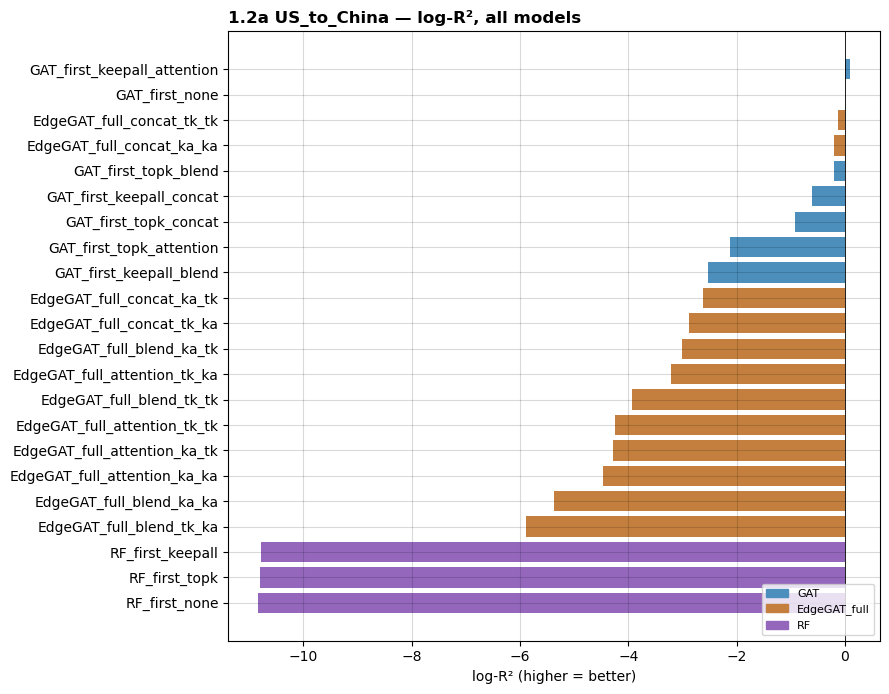

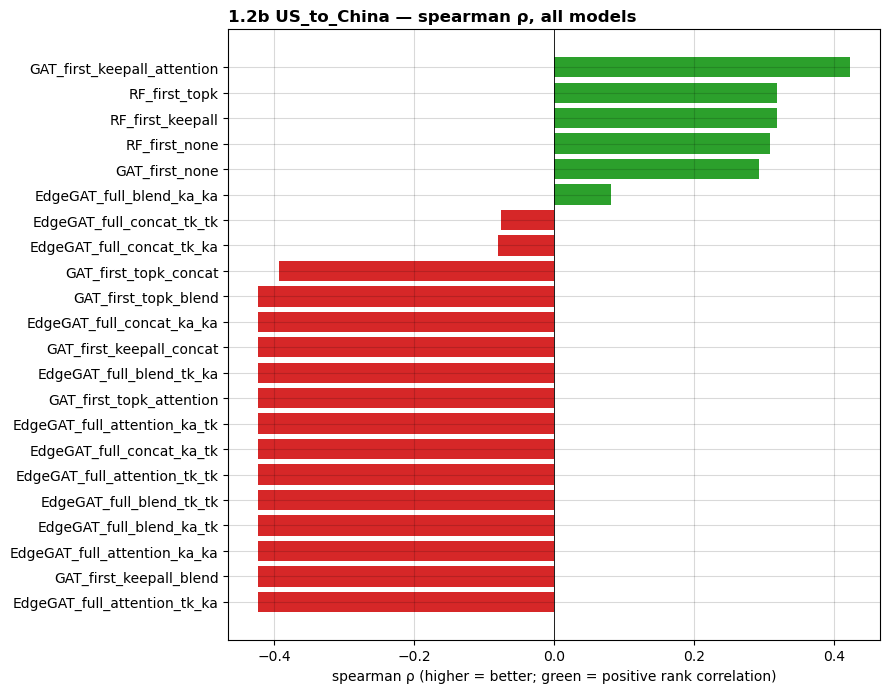

In [15]:
d = df[df.country_pair == 'US_to_China']

d1 = d.sort_values('log_r2', ascending=False)
fig, ax = plt.subplots(figsize=(9, max(5, 0.32*len(d1))))
colors = [KIND_COLOR.get(k, GRAY) for k in d1['kind']]
ax.barh(d1['model'], d1['log_r2'], color=colors)
ax.axvline(0, color='black', lw=.6)
ax.set_xlabel('log-R² (higher = better)')
ax.set_title('1.2a US_to_China — log-R², all models', loc='left', fontweight='bold')
ax.invert_yaxis()
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=BLUE, label='GAT'), Patch(color=ORANGE, label='EdgeGAT_full'),
                    Patch(color=PURPLE, label='RF')], fontsize=8, loc='lower right')
fig.tight_layout()

d2 = d.sort_values('spearman', ascending=False)
fig, ax = plt.subplots(figsize=(9, max(5, 0.32*len(d2))))
colors = [POS if v >= 0 else NEG for v in d2['spearman']]
ax.barh(d2['model'], d2['spearman'], color=colors)
ax.axvline(0, color='black', lw=.6)
ax.set_xlabel('spearman ρ (higher = better; green = positive rank correlation)')
ax.set_title('1.2b US_to_China — spearman ρ, all models', loc='left', fontweight='bold')
ax.invert_yaxis()
fig.tight_layout()

## 1.3 Error metrics — MAE, RMSE, SMAPE

R²/log-R²/spearman describe fit quality and ranking; these three describe the
actual dollar-and-percent size of the errors, which matters just as much for a paper
that wants to say something about real trade-value magnitudes.

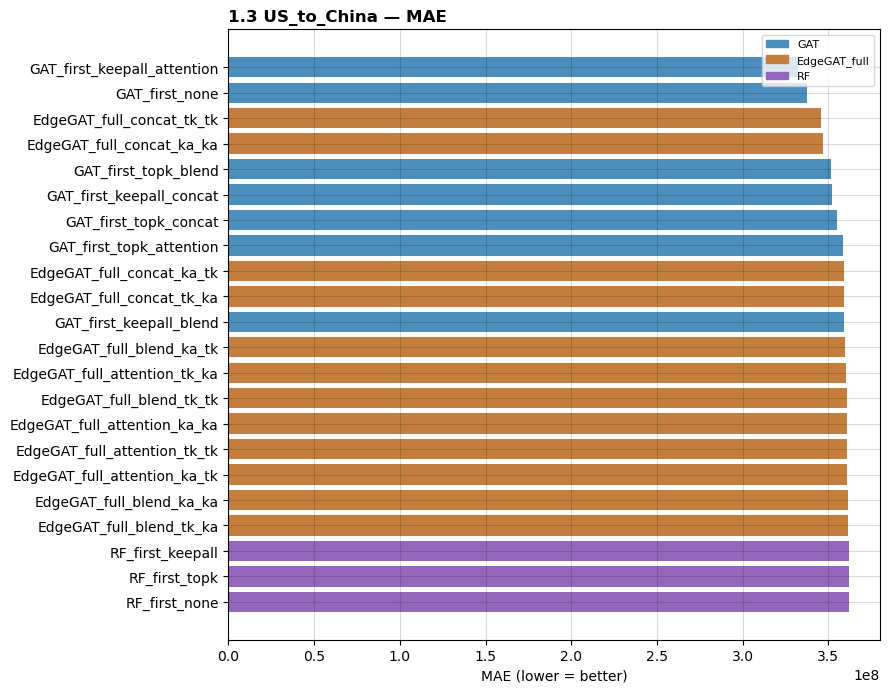

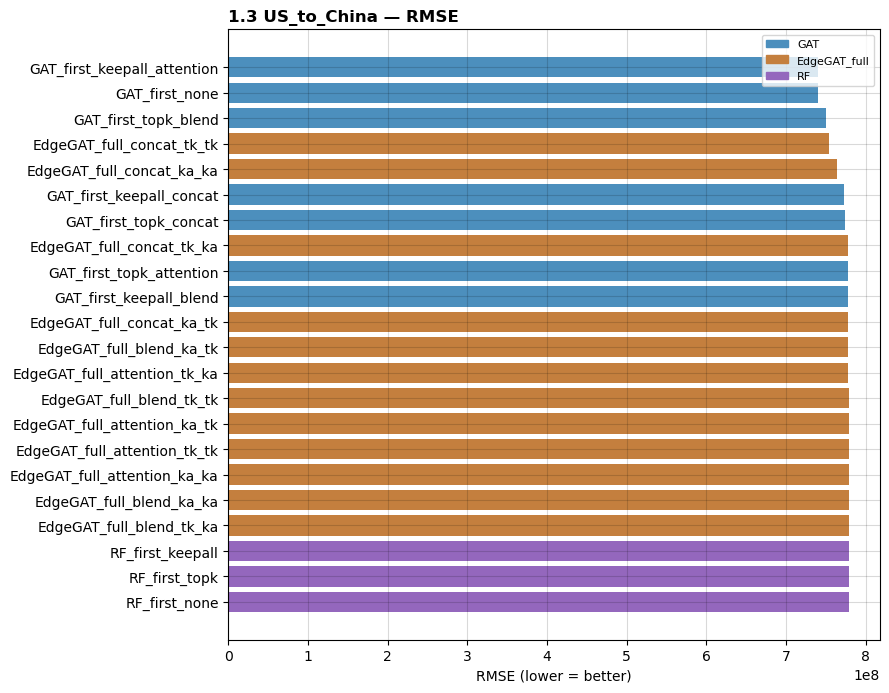

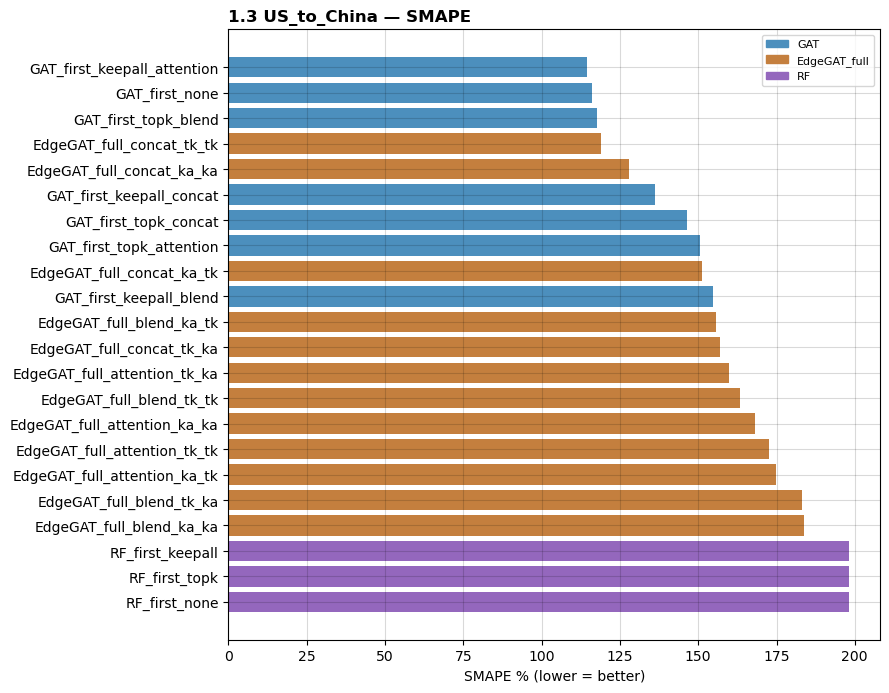

In [16]:
d = df[df.country_pair == 'US_to_China']

for metric, better in [('mae', 'lower'), ('rmse', 'lower'), ('smape', 'lower')]:
    dd = d.sort_values(metric, ascending=(better == 'lower'))
    fig, ax = plt.subplots(figsize=(9, max(5, 0.32*len(dd))))
    colors = [KIND_COLOR.get(k, GRAY) for k in dd['kind']]
    ax.barh(dd['model'], dd[metric], color=colors)
    ax.set_xlabel(METRIC_LABELS.get(metric, metric))
    ax.set_title(f'1.3 US_to_China — {metric.upper()}', loc='left', fontweight='bold')
    ax.invert_yaxis()
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color=BLUE, label='GAT'), Patch(color=ORANGE, label='EdgeGAT_full'),
                        Patch(color=PURPLE, label='RF')], fontsize=8)
    fig.tight_layout()

## 1.4 Best-of-family — no-GDELT GAT vs. GAT+GDELT vs. EdgeGAT_full vs. RF

Best achievable value in each bucket, across log-R², spearman, and the three error
metrics — same "best-of" framing as `compare_all_experiments_v3.ipynb` Section 1.

,log_r2,spearman,mae,rmse,smape
no-GDELT GAT,-0.0031,0.2930,3.374796e+08,7.402762e+08,116.15
GAT+GDELT (best),0.1013,0.4228,3.321173e+08,7.398092e+08,114.48
EdgeGAT_full (best),-0.1362,0.0807,3.455010e+08,7.546420e+08,119.11
RF (best),-10.7928,0.3174,3.620229e+08,7.791524e+08,198.07


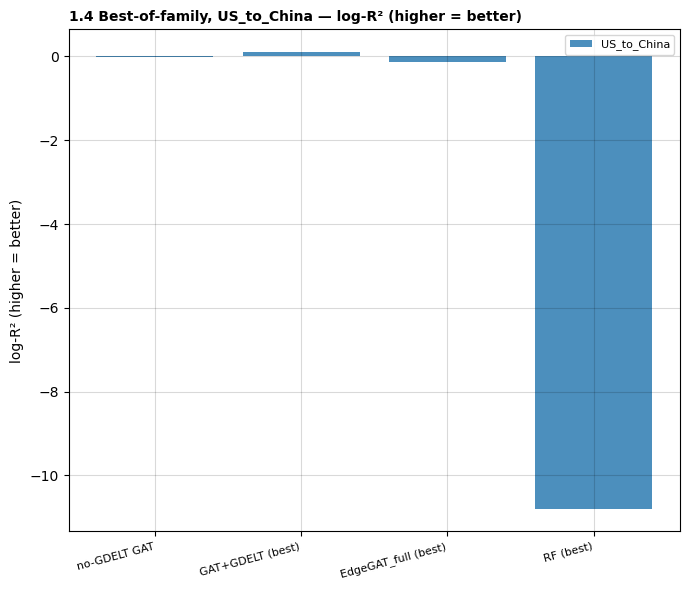

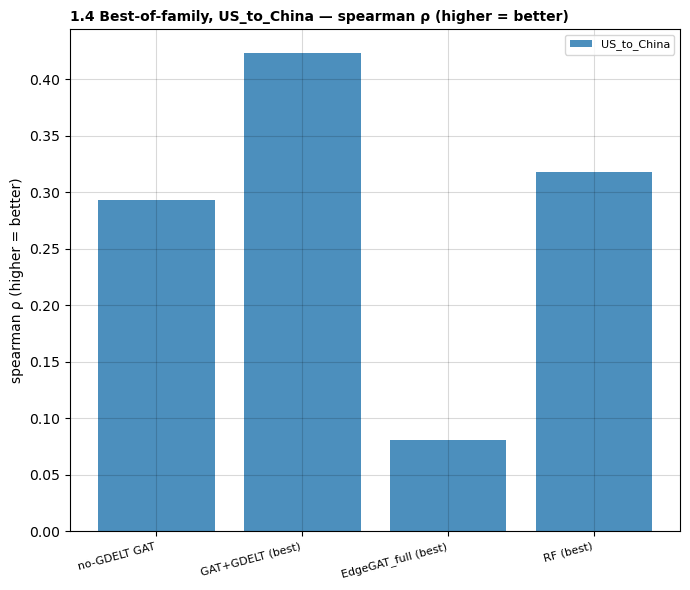

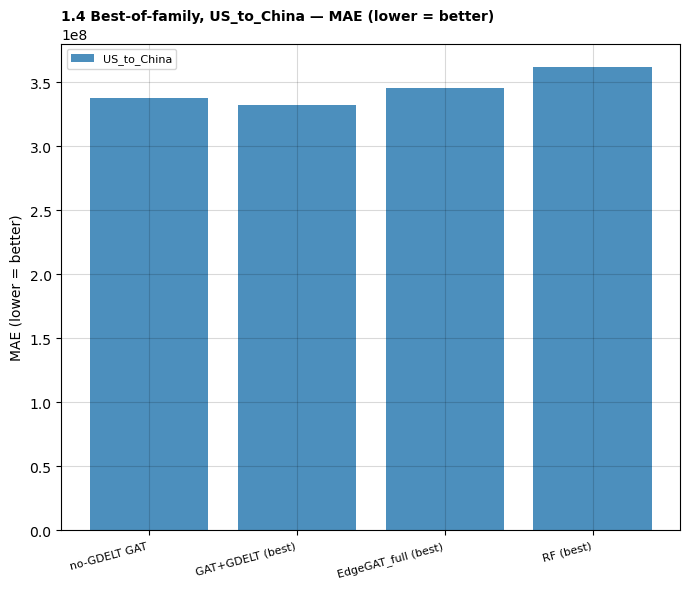

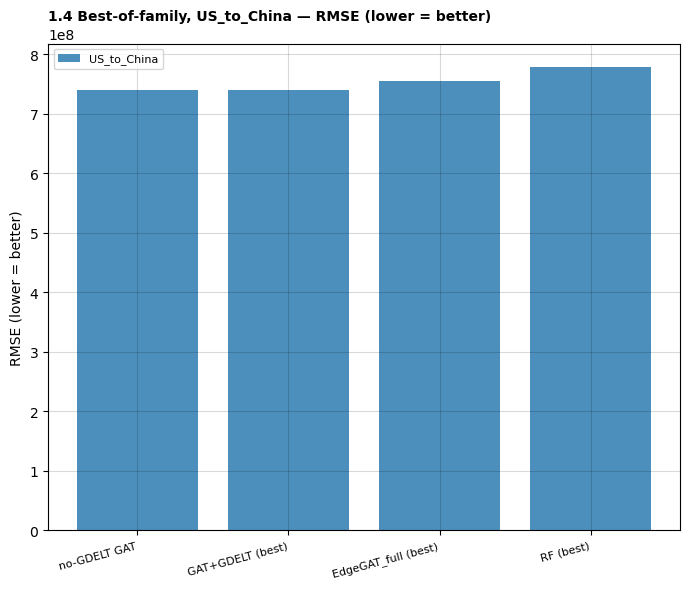

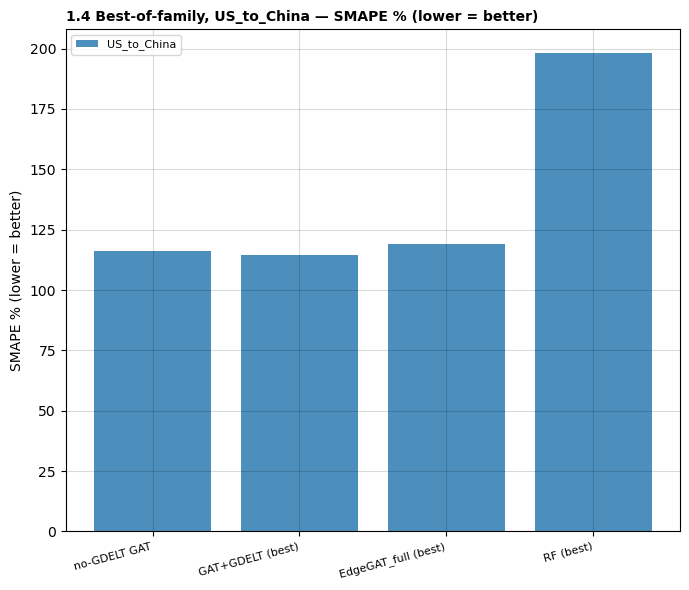

In [17]:
d = df[df.country_pair == 'US_to_China']
series = {'US_to_China': {m: [bucket_metrics(d, m)[k] for k in BUCKET_INDEX] for m in
                       ['log_r2', 'spearman', 'mae', 'rmse', 'smape']}}
plot_metric_mosaic(BUCKET_INDEX, series, metrics=['log_r2', 'spearman', 'mae', 'rmse', 'smape'],
                    metric_labels=METRIC_LABELS, title_prefix='1.4 Best-of-family, US_to_China',
                    orientation='vertical', rotation=15)

pd.DataFrame({m: bucket_metrics(d, m) for m in ['log_r2', 'spearman', 'mae', 'rmse', 'smape']},
             index=BUCKET_INDEX).round(4)

## 1.5 Does GDELT help on US_to_China specifically? (paired comparison)

Same exact config (model/fusion/scoring family), only GDELT presence differs. On n=19,
treat this as directional, not conclusive.

1.5 US_to_China — GDELT lift (mean-across-variants, paired):


,no_gdelt,gdelt_mean,lift
metric,,,
log_r2,-5.420400e+00,-3.405300e+00,2.015200e+00
spearman,3.008000e-01,-2.454000e-01,-5.462000e-01
mae,3.497528e+08,3.564899e+08,6.737041e+06
rmse,7.597146e+08,7.726727e+08,1.295815e+07
smape,1.571450e+02,1.566635e+02,-4.815000e-01


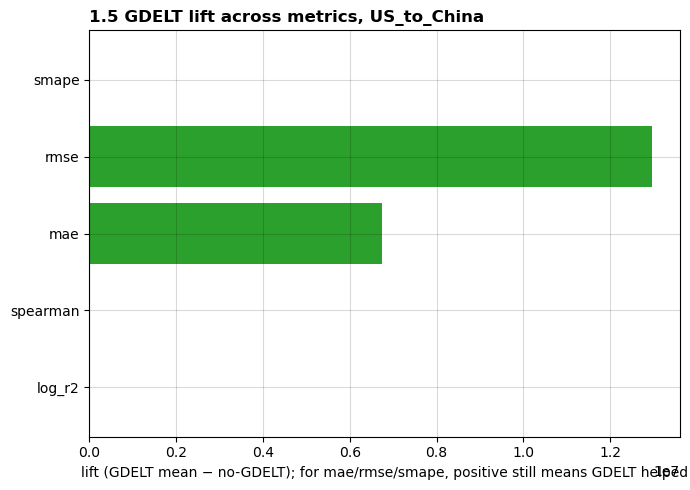

In [18]:
d = df[df.country_pair == 'US_to_China']
rows = []
for metric in ['log_r2', 'spearman', 'mae', 'rmse', 'smape']:
    base, g, lift = gdelt_lift(d, metric)
    rows.append({'metric': metric, 'no_gdelt': base, 'gdelt_mean': g, 'lift': lift})
lift_df = pd.DataFrame(rows).set_index('metric')
print('1.5 US_to_China — GDELT lift (mean-across-variants, paired):')
display(lift_df.round(4))

fig, ax = plt.subplots(figsize=(7, 5))
colors = [POS if v >= 0 else NEG for v in lift_df['lift']]
ax.barh(lift_df.index, lift_df['lift'], color=colors)
ax.axvline(0, color='black', lw=.6)
ax.set_xlabel('lift (GDELT mean − no-GDELT); for mae/rmse/smape, positive still means GDELT helped')
ax.set_title('1.5 GDELT lift across metrics, US_to_China', loc='left', fontweight='bold')
fig.tight_layout()

## 1.6 R² vs. log-R² agreement, US_to_China

Raw-scale R² is unreliable on this heavy-tailed target (established project
convention: log-space is primary). Checking whether the two at least agree on ranking.

US_to_China: biggest rank disagreements (raw R² rank vs log-R² rank):
model
EdgeGAT_full_concat_tk_ka    3.0
GAT_first_topk_blend         2.0
GAT_first_keepall_blend      1.0
RF_first_keepall             1.0
RF_first_none                1.0


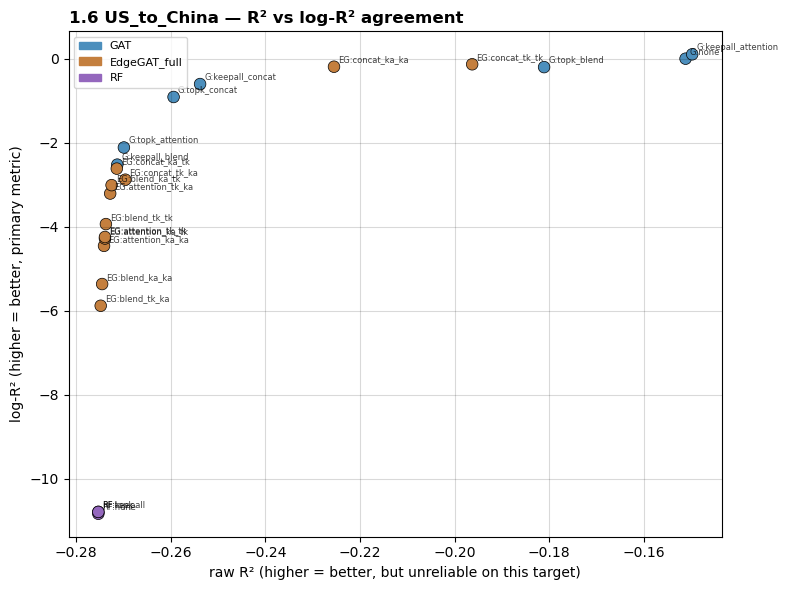

In [19]:
d = df[df.country_pair == 'US_to_China']
fig, ax = plt.subplots(figsize=(8, 6))
colors = [KIND_COLOR.get(k, GRAY) for k in d['kind']]
ax.scatter(d['r2'], d['log_r2'], c=colors, s=70, edgecolor='black', linewidth=0.5)
for _, row in d.iterrows():
    label = row['model'].replace('EdgeGAT_full_', 'EG:').replace('GAT_first_', 'G:').replace('RF_first_', 'RF:')
    ax.annotate(label, (row['r2'], row['log_r2']), fontsize=6, alpha=0.75,
                xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('raw R² (higher = better, but unreliable on this target)')
ax.set_ylabel('log-R² (higher = better, primary metric)')
ax.set_title('1.6 US_to_China — R² vs log-R² agreement', loc='left', fontweight='bold')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=BLUE, label='GAT'), Patch(color=ORANGE, label='EdgeGAT_full'),
                    Patch(color=PURPLE, label='RF')], fontsize=8)
fig.tight_layout()

rank_r2 = d.set_index('model')['r2'].rank(ascending=False)
rank_logr2 = d.set_index('model')['log_r2'].rank(ascending=False)
disagree = (rank_r2 - rank_logr2).abs().sort_values(ascending=False)
print('US_to_China: biggest rank disagreements (raw R² rank vs log-R² rank):')
print(disagree.head(5).to_string())

---
# Part 2. China → Taiwan — full story

Everything in this section is scoped to `country_pair == 'China_to_Taiwan'` only. Part 3 brings
both corridors back together for a direct comparison.

## 2.1 Overview table

In [20]:
d = df[df.country_pair == 'China_to_Taiwan'][['model', 'kind', 'use_gdelt', 'scoring', 'fusion',
                                    'n', 'mae', 'rmse', 'r2', 'log_r2', 'spearman', 'smape']]
d = d.sort_values('log_r2', ascending=False).reset_index(drop=True)
print(f'China_to_Taiwan: {len(d)} models')
display(d.round(4))

China_to_Taiwan: 22 models


,model,kind,use_gdelt,scoring,fusion,n,mae,rmse,r2,log_r2,spearman,smape
0,EdgeGAT_full_blend_tk_tk,EdgeGAT_full,True,tk_tk,blend,19,1.181604e+09,2.768675e+09,-0.1914,0.0270,0.1509,130.76
1,GAT_first_keepall_blend,GAT,True,keepall,blend,19,1.227767e+09,2.690970e+09,-0.1255,-0.0538,0.3333,146.10
2,EdgeGAT_full_blend_ka_tk,EdgeGAT_full,True,ka_tk,blend,19,1.190832e+09,2.789370e+09,-0.2093,-0.0833,-0.3333,135.36
3,EdgeGAT_full_concat_tk_tk,EdgeGAT_full,True,tk_tk,concat,19,1.189579e+09,2.757019e+09,-0.1814,-0.1014,-0.1509,127.75
4,EdgeGAT_full_attention_ka_tk,EdgeGAT_full,True,ka_tk,attention,19,1.193083e+09,2.795862e+09,-0.2149,-0.1186,0.1509,138.28
5,EdgeGAT_full_concat_tk_ka,EdgeGAT_full,True,tk_ka,concat,19,1.195540e+09,2.774445e+09,-0.1964,-0.1816,-0.3333,127.20
6,GAT_first_keepall_concat,GAT,True,keepall,concat,19,1.197445e+09,2.799537e+09,-0.2181,-0.2112,-0.1509,145.19
7,EdgeGAT_full_concat_ka_ka,EdgeGAT_full,True,ka_ka,concat,19,1.248369e+09,2.673413e+09,-0.1108,-0.2348,-0.1509,140.55
8,EdgeGAT_full_blend_ka_ka,EdgeGAT_full,True,ka_ka,blend,19,1.199733e+09,2.799251e+09,-0.2179,-0.2529,-0.3333,149.97
9,EdgeGAT_full_concat_ka_tk,EdgeGAT_full,True,ka_tk,concat,19,1.259443e+09,2.663871e+09,-0.1029,-0.2749,-0.1509,140.50


## 2.2 Ranking — log-R² and spearman ρ

Bars colored by model family (GAT / EdgeGAT_full / RF).

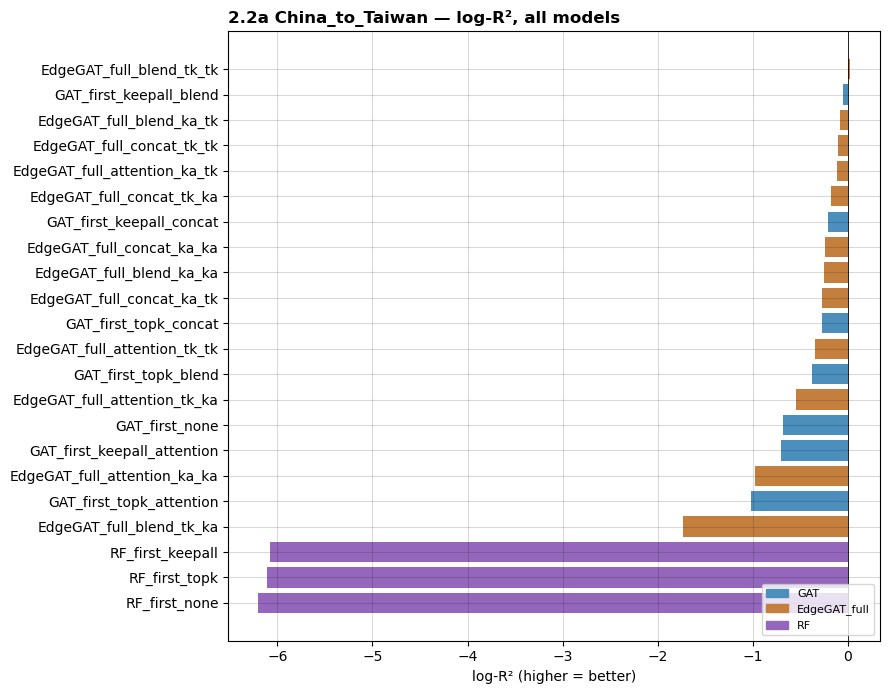

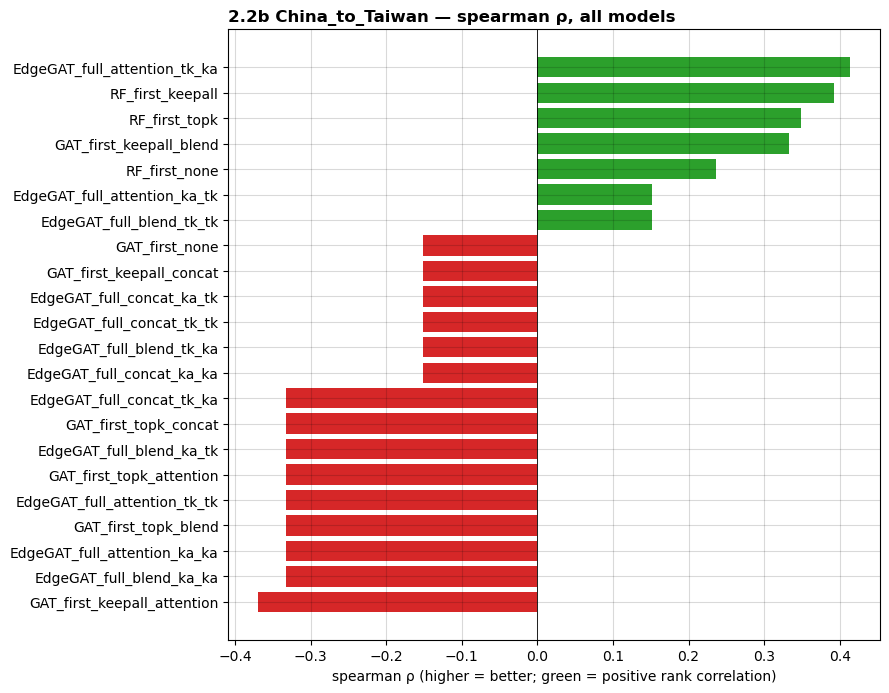

In [21]:
d = df[df.country_pair == 'China_to_Taiwan']

d1 = d.sort_values('log_r2', ascending=False)
fig, ax = plt.subplots(figsize=(9, max(5, 0.32*len(d1))))
colors = [KIND_COLOR.get(k, GRAY) for k in d1['kind']]
ax.barh(d1['model'], d1['log_r2'], color=colors)
ax.axvline(0, color='black', lw=.6)
ax.set_xlabel('log-R² (higher = better)')
ax.set_title('2.2a China_to_Taiwan — log-R², all models', loc='left', fontweight='bold')
ax.invert_yaxis()
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=BLUE, label='GAT'), Patch(color=ORANGE, label='EdgeGAT_full'),
                    Patch(color=PURPLE, label='RF')], fontsize=8, loc='lower right')
fig.tight_layout()

d2 = d.sort_values('spearman', ascending=False)
fig, ax = plt.subplots(figsize=(9, max(5, 0.32*len(d2))))
colors = [POS if v >= 0 else NEG for v in d2['spearman']]
ax.barh(d2['model'], d2['spearman'], color=colors)
ax.axvline(0, color='black', lw=.6)
ax.set_xlabel('spearman ρ (higher = better; green = positive rank correlation)')
ax.set_title('2.2b China_to_Taiwan — spearman ρ, all models', loc='left', fontweight='bold')
ax.invert_yaxis()
fig.tight_layout()

## 2.3 Error metrics — MAE, RMSE, SMAPE

R²/log-R²/spearman describe fit quality and ranking; these three describe the
actual dollar-and-percent size of the errors, which matters just as much for a paper
that wants to say something about real trade-value magnitudes.

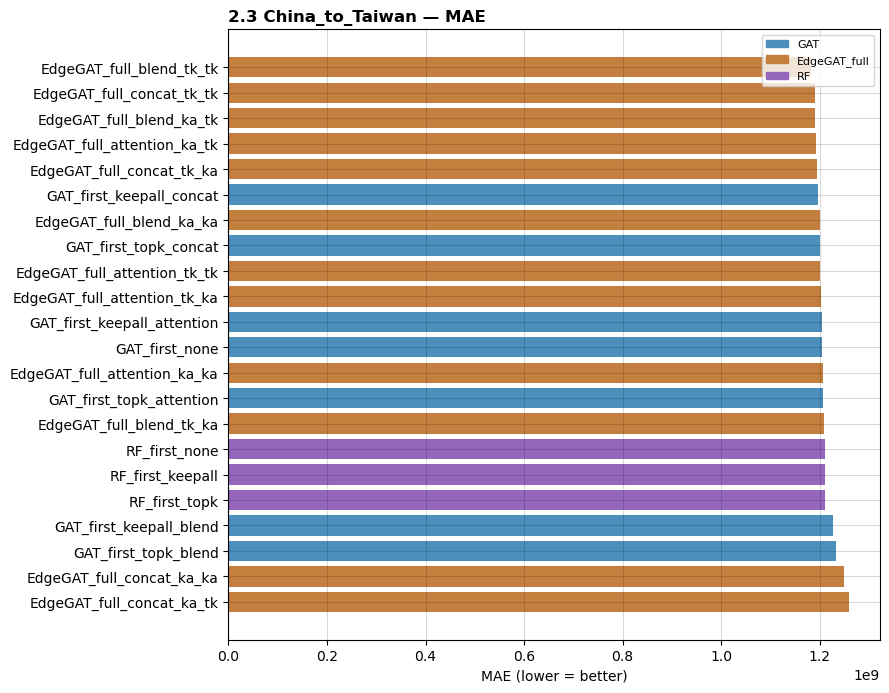

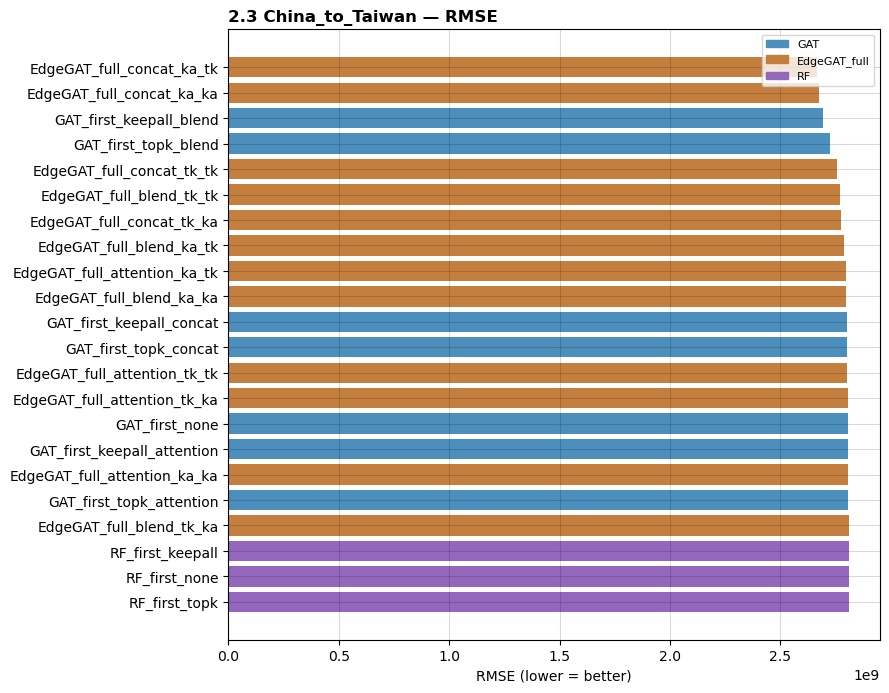

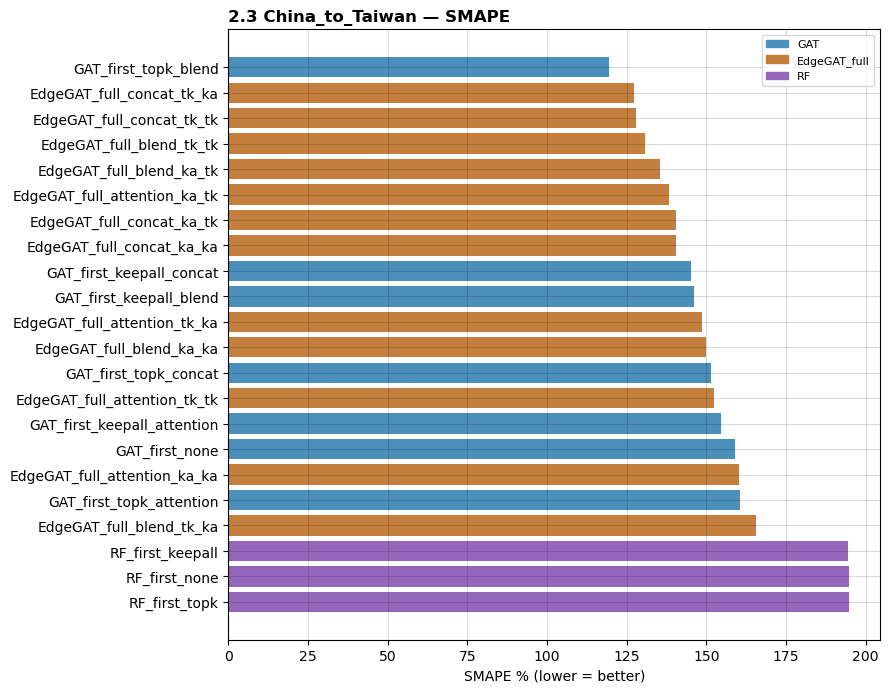

In [22]:
d = df[df.country_pair == 'China_to_Taiwan']

for metric, better in [('mae', 'lower'), ('rmse', 'lower'), ('smape', 'lower')]:
    dd = d.sort_values(metric, ascending=(better == 'lower'))
    fig, ax = plt.subplots(figsize=(9, max(5, 0.32*len(dd))))
    colors = [KIND_COLOR.get(k, GRAY) for k in dd['kind']]
    ax.barh(dd['model'], dd[metric], color=colors)
    ax.set_xlabel(METRIC_LABELS.get(metric, metric))
    ax.set_title(f'2.3 China_to_Taiwan — {metric.upper()}', loc='left', fontweight='bold')
    ax.invert_yaxis()
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color=BLUE, label='GAT'), Patch(color=ORANGE, label='EdgeGAT_full'),
                        Patch(color=PURPLE, label='RF')], fontsize=8)
    fig.tight_layout()

## 2.4 Best-of-family — no-GDELT GAT vs. GAT+GDELT vs. EdgeGAT_full vs. RF

Best achievable value in each bucket, across log-R², spearman, and the three error
metrics — same "best-of" framing as `compare_all_experiments_v3.ipynb` Section 1.

,log_r2,spearman,mae,rmse,smape
no-GDELT GAT,-0.6820,-0.1509,1.205333e+09,2.806868e+09,158.98
GAT+GDELT (best),-0.0538,0.3333,1.197445e+09,2.690970e+09,119.35
EdgeGAT_full (best),0.0270,0.4140,1.181604e+09,2.663871e+09,127.20
RF (best),-6.0760,0.3917,1.210980e+09,2.810728e+09,194.48


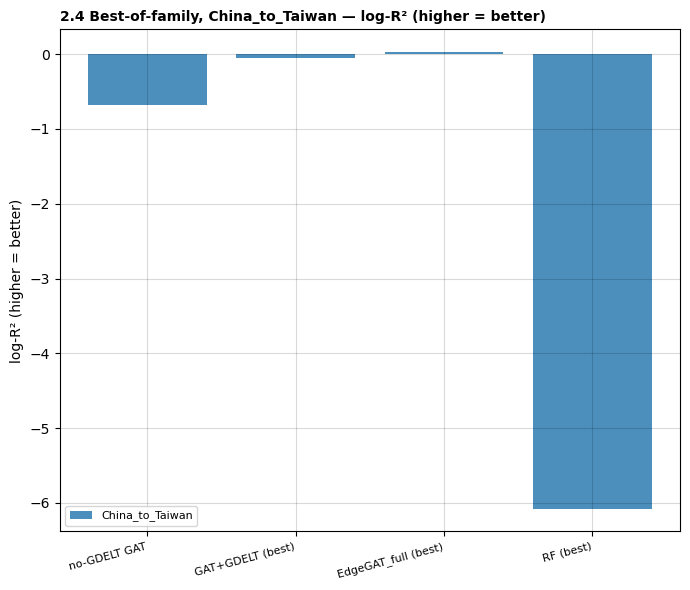

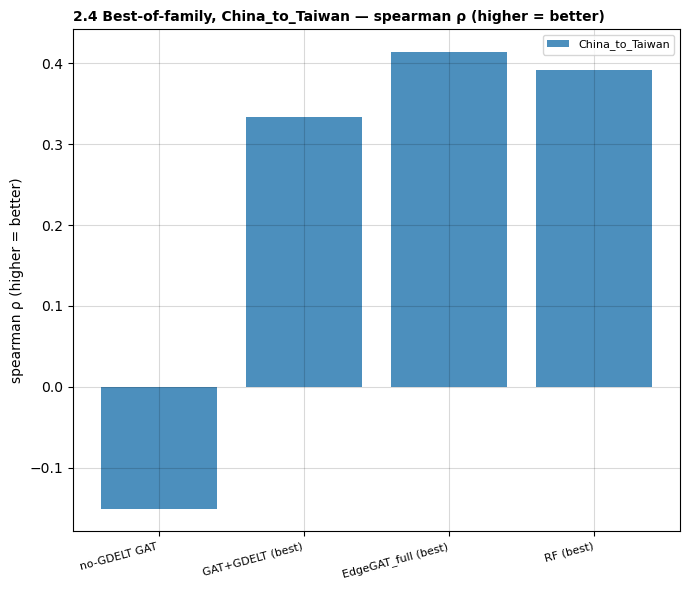

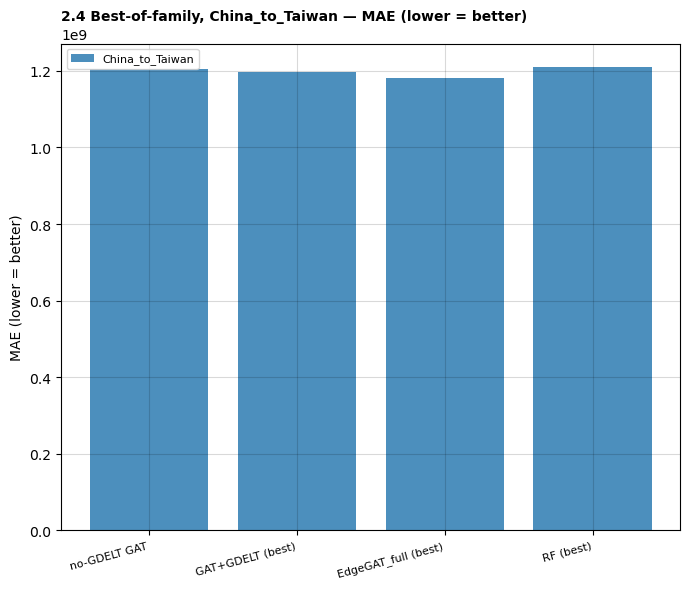

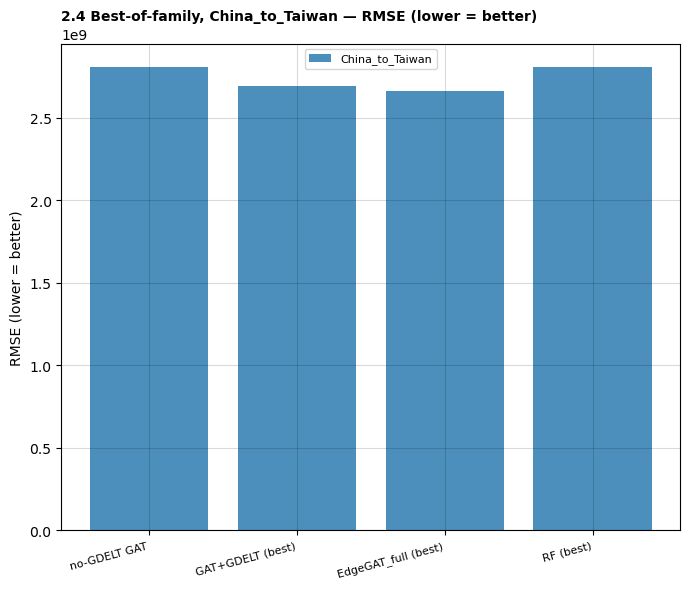

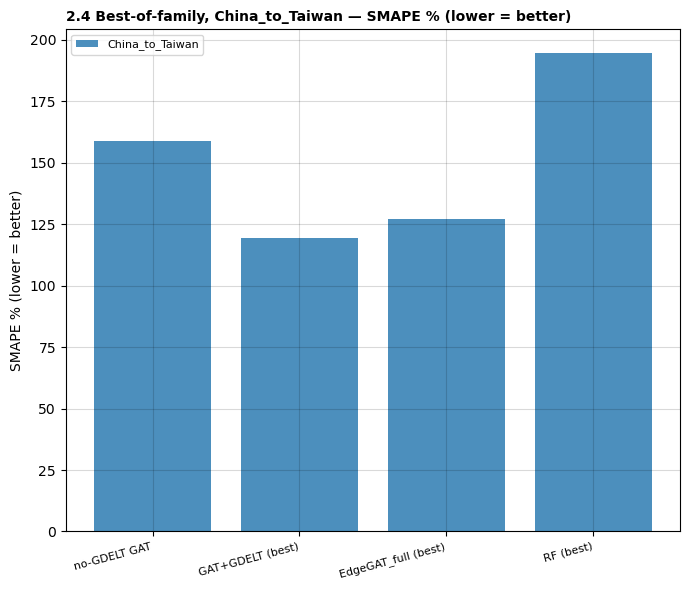

In [23]:
d = df[df.country_pair == 'China_to_Taiwan']
series = {'China_to_Taiwan': {m: [bucket_metrics(d, m)[k] for k in BUCKET_INDEX] for m in
                       ['log_r2', 'spearman', 'mae', 'rmse', 'smape']}}
plot_metric_mosaic(BUCKET_INDEX, series, metrics=['log_r2', 'spearman', 'mae', 'rmse', 'smape'],
                    metric_labels=METRIC_LABELS, title_prefix='2.4 Best-of-family, China_to_Taiwan',
                    orientation='vertical', rotation=15)

pd.DataFrame({m: bucket_metrics(d, m) for m in ['log_r2', 'spearman', 'mae', 'rmse', 'smape']},
             index=BUCKET_INDEX).round(4)

## 2.5 Does GDELT help on China_to_Taiwan specifically? (paired comparison)

Same exact config (model/fusion/scoring family), only GDELT presence differs. On n=19,
treat this as directional, not conclusive.

2.5 China_to_Taiwan — GDELT lift (mean-across-variants, paired):


,no_gdelt,gdelt_mean,lift
metric,,,
log_r2,-3.442300e+00,-9.819000e-01,2.460400e+00
spearman,4.260000e-02,-1.000000e-01,-1.426000e-01
mae,1.208156e+09,1.208548e+09,3.916613e+05
rmse,2.808798e+09,2.775122e+09,-3.367622e+07
smape,1.768400e+02,1.491815e+02,-2.765850e+01


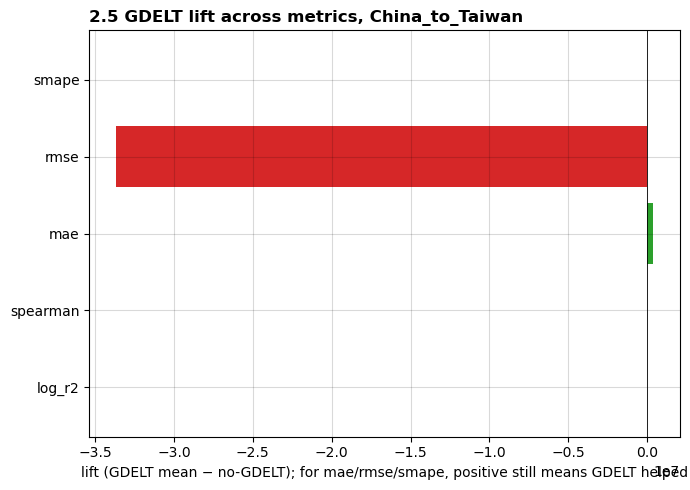

In [24]:
d = df[df.country_pair == 'China_to_Taiwan']
rows = []
for metric in ['log_r2', 'spearman', 'mae', 'rmse', 'smape']:
    base, g, lift = gdelt_lift(d, metric)
    rows.append({'metric': metric, 'no_gdelt': base, 'gdelt_mean': g, 'lift': lift})
lift_df = pd.DataFrame(rows).set_index('metric')
print('2.5 China_to_Taiwan — GDELT lift (mean-across-variants, paired):')
display(lift_df.round(4))

fig, ax = plt.subplots(figsize=(7, 5))
colors = [POS if v >= 0 else NEG for v in lift_df['lift']]
ax.barh(lift_df.index, lift_df['lift'], color=colors)
ax.axvline(0, color='black', lw=.6)
ax.set_xlabel('lift (GDELT mean − no-GDELT); for mae/rmse/smape, positive still means GDELT helped')
ax.set_title('2.5 GDELT lift across metrics, China_to_Taiwan', loc='left', fontweight='bold')
fig.tight_layout()

## 2.6 R² vs. log-R² agreement, China_to_Taiwan

Raw-scale R² is unreliable on this heavy-tailed target (established project
convention: log-space is primary). Checking whether the two at least agree on ranking.

China_to_Taiwan: biggest rank disagreements (raw R² rank vs log-R² rank):
model
GAT_first_topk_blend         9.0
EdgeGAT_full_concat_ka_tk    9.0
EdgeGAT_full_concat_ka_ka    6.0
EdgeGAT_full_blend_tk_tk     5.0
EdgeGAT_full_blend_ka_tk     5.0


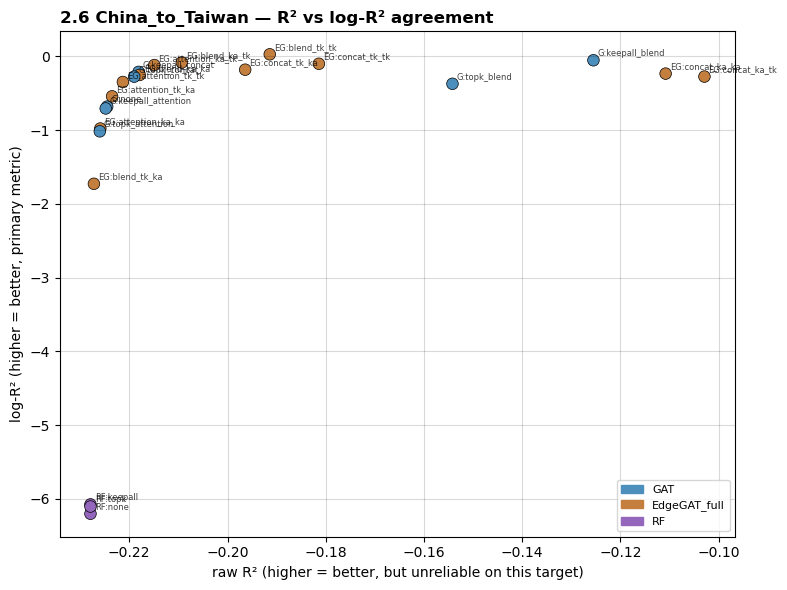

In [25]:
d = df[df.country_pair == 'China_to_Taiwan']
fig, ax = plt.subplots(figsize=(8, 6))
colors = [KIND_COLOR.get(k, GRAY) for k in d['kind']]
ax.scatter(d['r2'], d['log_r2'], c=colors, s=70, edgecolor='black', linewidth=0.5)
for _, row in d.iterrows():
    label = row['model'].replace('EdgeGAT_full_', 'EG:').replace('GAT_first_', 'G:').replace('RF_first_', 'RF:')
    ax.annotate(label, (row['r2'], row['log_r2']), fontsize=6, alpha=0.75,
                xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('raw R² (higher = better, but unreliable on this target)')
ax.set_ylabel('log-R² (higher = better, primary metric)')
ax.set_title('2.6 China_to_Taiwan — R² vs log-R² agreement', loc='left', fontweight='bold')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=BLUE, label='GAT'), Patch(color=ORANGE, label='EdgeGAT_full'),
                    Patch(color=PURPLE, label='RF')], fontsize=8)
fig.tight_layout()

rank_r2 = d.set_index('model')['r2'].rank(ascending=False)
rank_logr2 = d.set_index('model')['log_r2'].rank(ascending=False)
disagree = (rank_r2 - rank_logr2).abs().sort_values(ascending=False)
print('China_to_Taiwan: biggest rank disagreements (raw R² rank vs log-R² rank):')
print(disagree.head(5).to_string())

---
# Part 3. US→China vs. China→Taiwan — direct comparison

Both corridors, side by side, across every metric.

## 3.1 Per-model comparison, both corridors

Same model, both corridors, grouped bars — is either corridor systematically harder?

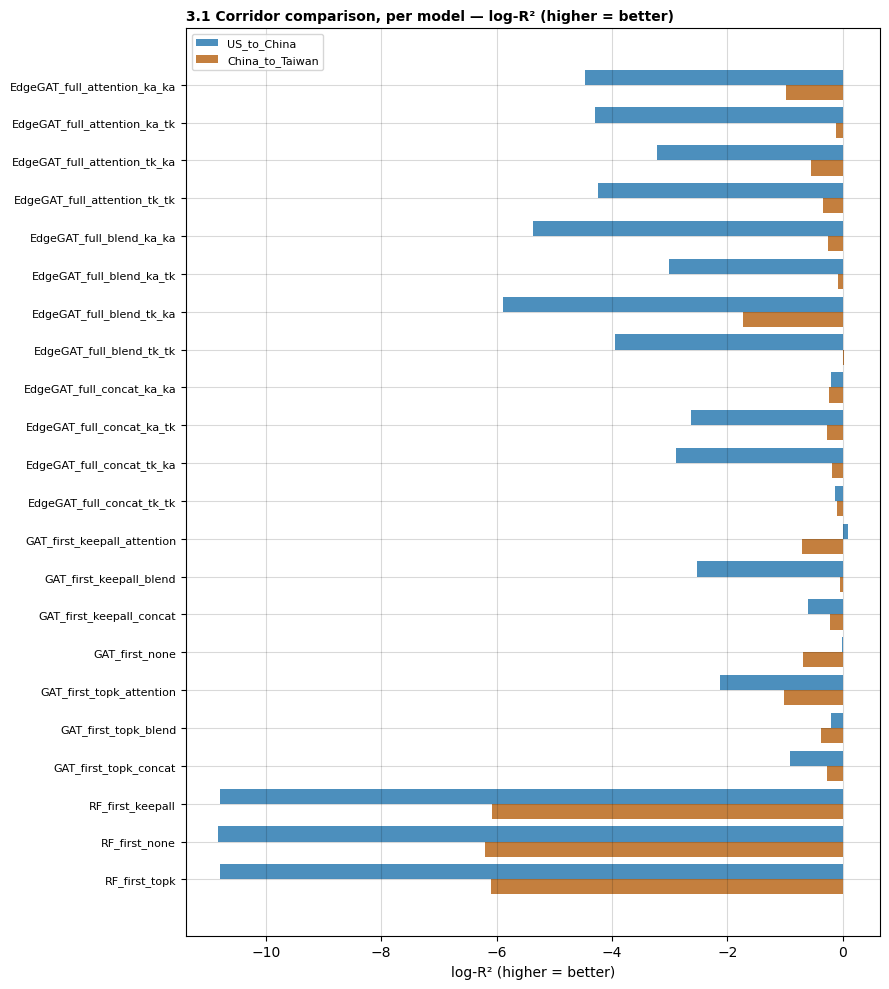

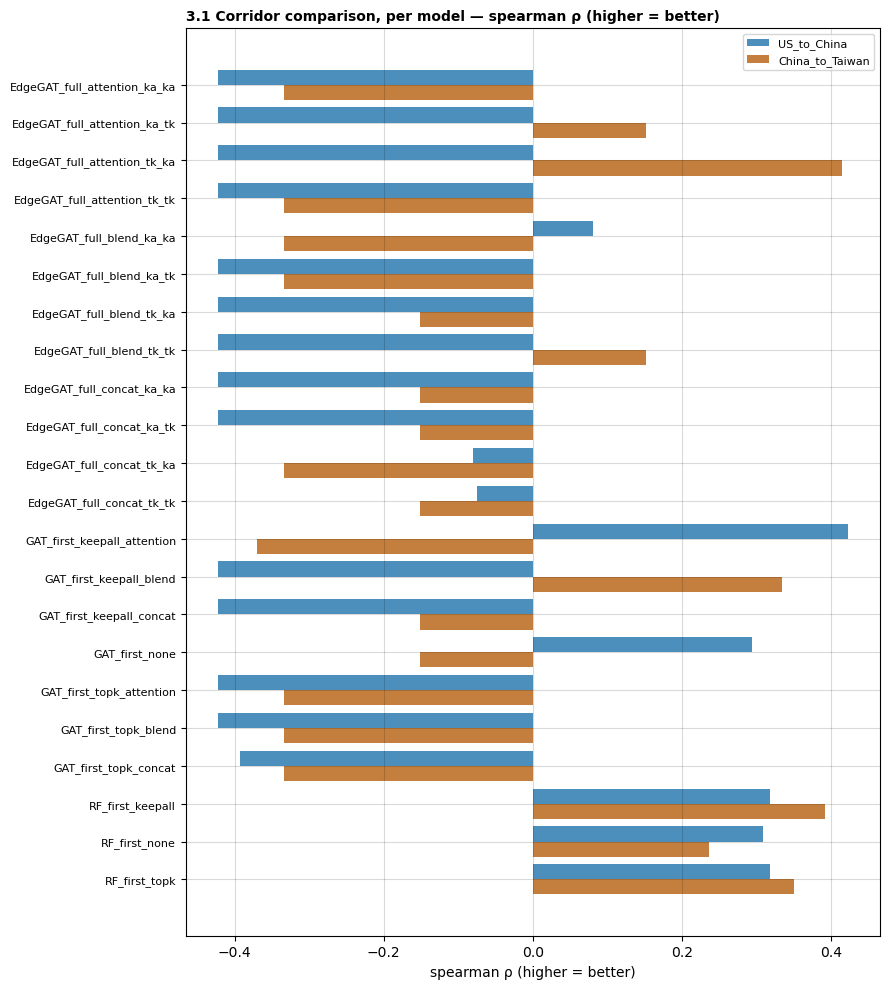

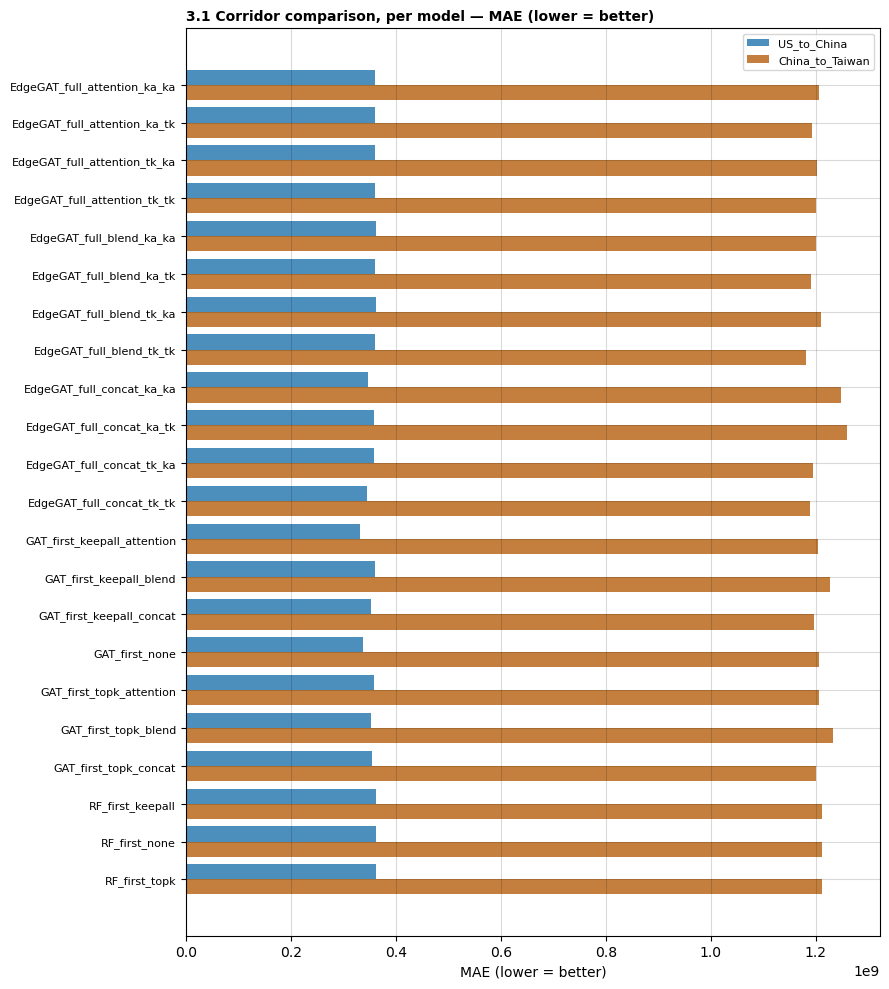

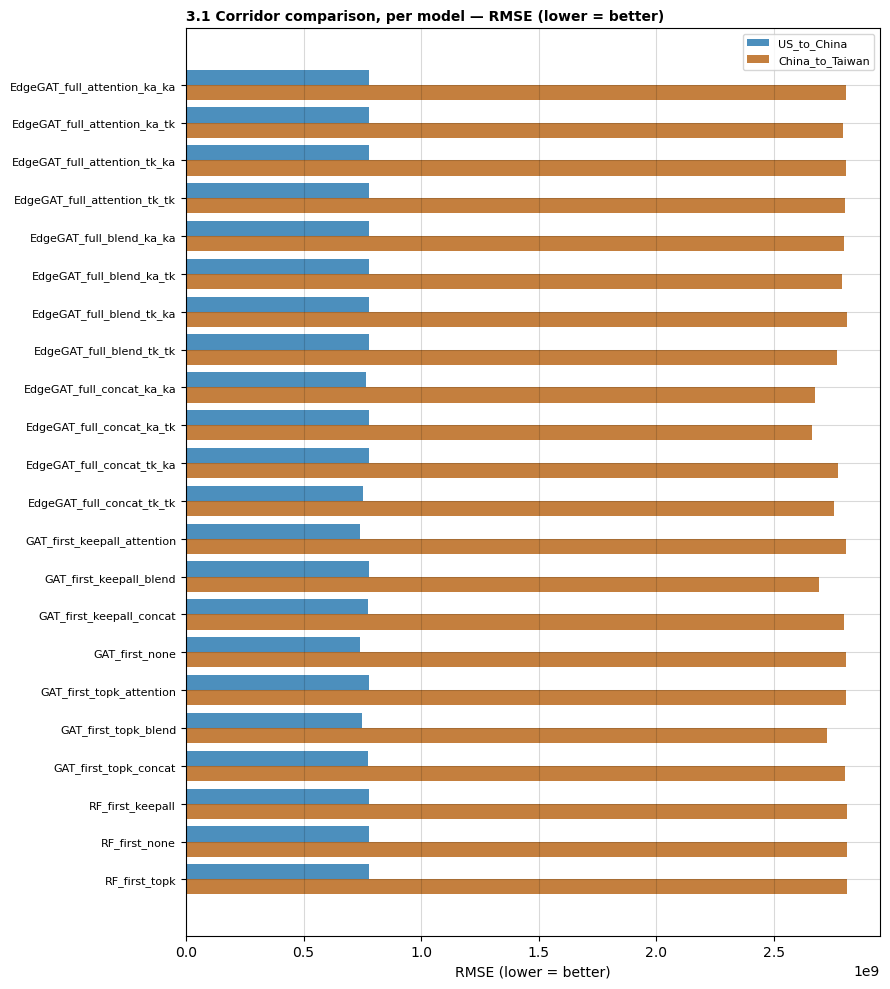

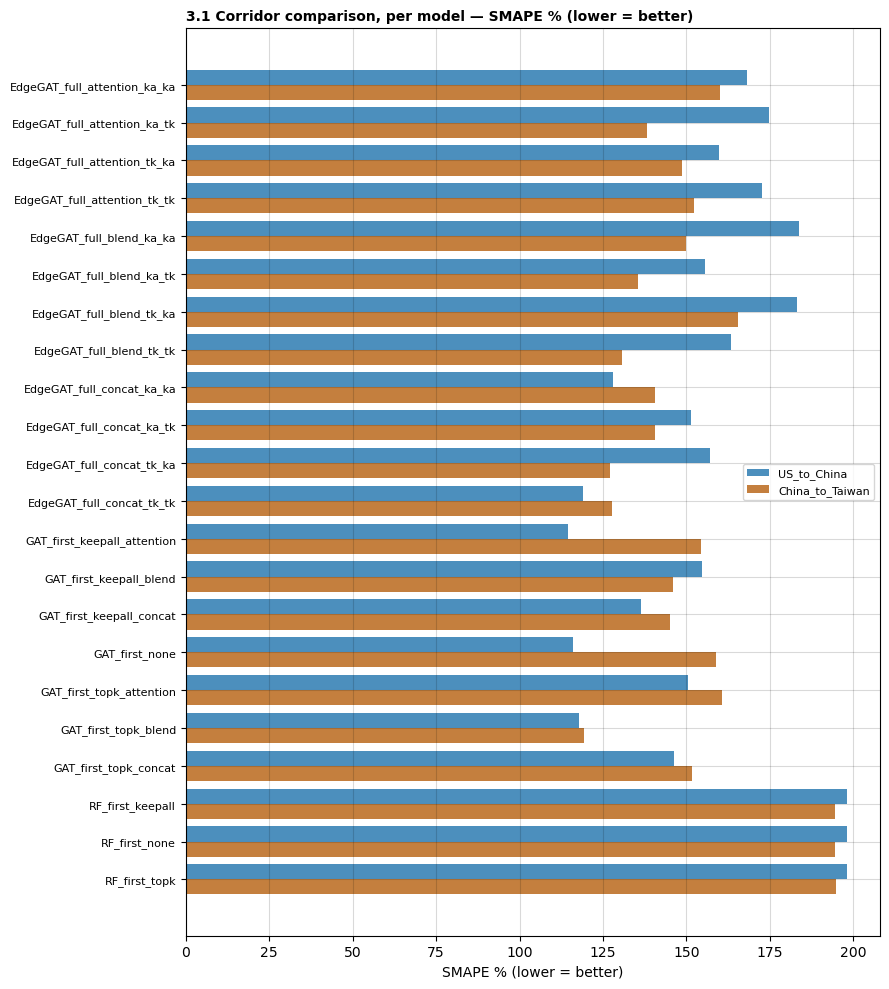

In [26]:
models_common = sorted(set(df[df.country_pair == 'US_to_China']['model']) &
                        set(df[df.country_pair == 'China_to_Taiwan']['model']))

if models_common:
    series_31 = {}
    for pair in ['US_to_China', 'China_to_Taiwan']:
        d = df[df.country_pair == pair].set_index('model').loc[models_common]
        series_31[pair] = {m: d[m].values for m in ['log_r2', 'spearman', 'mae', 'rmse', 'smape']}
    plot_metric_mosaic(models_common, series_31, metrics=['log_r2', 'spearman', 'mae', 'rmse', 'smape'],
                        metric_labels=METRIC_LABELS, title_prefix='3.1 Corridor comparison, per model',
                        panel_size=(9, 10))
else:
    print('[skip] no overlapping models between the two corridors')

## 3.2 Which corridor is harder overall? (best-of-family, side by side)

,best_log_r2,best_spearman,best_mae,best_rmse,best_smape
country_pair,,,,,
US_to_China,0.1013,0.4228,3.321173e+08,7.398092e+08,114.48
China_to_Taiwan,0.0270,0.4140,1.181604e+09,2.663871e+09,119.35


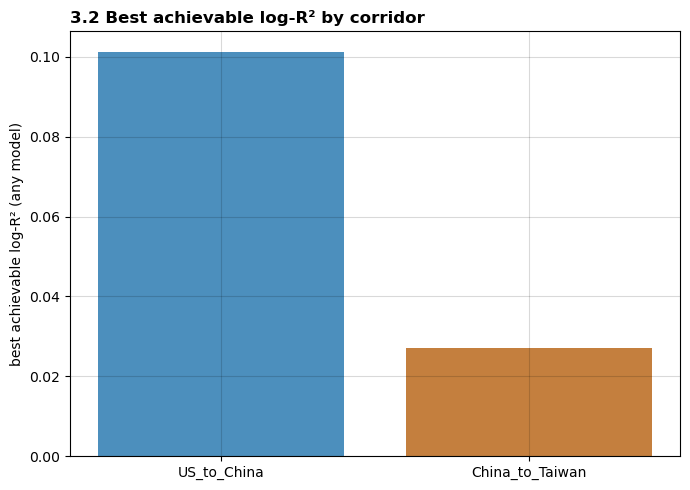

In [27]:
rows = []
for pair in ['US_to_China', 'China_to_Taiwan']:
    d = df[df.country_pair == pair]
    row = {'country_pair': pair}
    for metric in ['log_r2', 'spearman', 'mae', 'rmse', 'smape']:
        best = bucket_metrics(d, metric)
        row[f'best_{metric}'] = max(best.values()) if metric not in ('mae', 'rmse', 'smape') else min(
            v for v in best.values() if not np.isnan(v))
    rows.append(row)
corridor_best = pd.DataFrame(rows).set_index('country_pair')
display(corridor_best.round(4))

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(corridor_best.index, corridor_best['best_log_r2'], color=[BLUE, ORANGE])
ax.axhline(0, color='black', lw=.6)
ax.set_ylabel('best achievable log-R\u00b2 (any model)')
ax.set_title('3.2 Best achievable log-R\u00b2 by corridor', loc='left', fontweight='bold')
fig.tight_layout()

## 3.3 Closing caveats (read before writing this into the paper)

- **Negative log-R\u00b2 across nearly every model, both corridors.** At n=19 this is
  plausible sampling noise, not necessarily a real architectural failure — but it's also
  not evidence of a genuine lift from any particular model family on these two corridors
  specifically.
- **No time dimension yet.** This is a single 2023 snapshot per corridor. The more
  compelling version of this analysis — and the one worth writing into the paper — is a
  predicted-vs-actual time series across 2017\u20132023 for each corridor, annotated
  against known events (Oct-2022 export controls, entity-list additions, etc.). That
  extension is still open.
- **GDELT lift (Part 1.5 / Part 2.5) is inconclusive at this scope.** Don't state a
  positive or negative GDELT effect for these two corridors specifically based on this
  file alone.
- Rerun this notebook after any future `test_bilateral_pairs.py` run — the dedup logic
  in the load cell handles re-appends automatically, but always check the "models with
  unresolved cells" printout in the load cell before trusting a chart.